<a href="https://colab.research.google.com/github/YolandaZhao10/CSCI-6170-Project-in-AI-and-ML/blob/main/hw3/homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1

In [3]:
import numpy as np
from sklearn.datasets import fetch_covtype

def train_test_split(X, y, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)
    split = int(len(X) * (1 - test_size))
    tr, te = idx[:split], idx[split:]
    return X[tr], X[te], y[tr], y[te]

# 1. Load dataset
data = fetch_covtype()
X = data.data.astype(float)
y = data.target - 1  # make classes 0–6

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [4]:
class StandardScalerNP:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0, keepdims=True)
        self.std_ = X.std(axis=0, keepdims=True)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

def one_hot(y, num_classes):
    y = y.astype(int)
    out = np.zeros((len(y), num_classes))
    out[np.arange(len(y)), y] = 1
    return out


# 3. Scale
scaler = StandardScalerNP()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. One-hot labels
num_classes = len(np.unique(y))
y_train_oh = one_hot(y_train, num_classes)
y_test_oh = one_hot(y_test, num_classes)

In [8]:
class NeuralNetwork:
    def __init__(self, layer_sizes, activations=None, seed=42):
        self.layer_sizes = layer_sizes
        self.L = len(layer_sizes) - 1

        if activations is None:
            activations = ["relu"] * (self.L - 1)
        self.hidden_activations = activations

        self.rng = np.random.default_rng(seed)
        self.params = self._init_params()

    def _init_params(self):
        params = {}
        for l in range(1, self.L + 1):
            fan_in = self.layer_sizes[l - 1]
            scale = np.sqrt(2.0 / fan_in)
            params[f"W{l}"] = self.rng.normal(0, scale,
                                              size=(fan_in, self.layer_sizes[l]))
            params[f"b{l}"] = np.zeros((1, self.layer_sizes[l]))
        return params

    # activations
    def relu(Z): return np.maximum(0, Z)
    def drelu(Z): return (Z > 0).astype(Z.dtype)

    def softmax(Z):
        Z = Z - np.max(Z, axis=1, keepdims=True)
        exp = np.exp(Z)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def forward_propagation(self, X):
        cache = {"A0": X}
        A = X

        # hidden layers
        for l in range(1, self.L):
            W, b = self.params[f"W{l}"], self.params[f"b{l}"]
            Z = A @ W + b
            cache[f"Z{l}"] = Z
            A = self.relu(Z)
            cache[f"A{l}"] = A

        # output layer
        W, b = self.params[f"W{self.L}"], self.params[f"b{self.L}"]
        ZL = A @ W + b
        AL = self.softmax(ZL)

        cache[f"Z{self.L}"] = ZL
        cache[f"A{self.L}"] = AL
        return AL, cache

    def cost(self, y_true, y_prob):
        eps = 1e-12
        y_prob = np.clip(y_prob, eps, 1 - eps)
        return -np.mean(np.sum(y_true * np.log(y_prob), axis=1))

    def backward_propagation(self, y_true, cache):
        grads = {}
        N = y_true.shape[0]

        AL = cache[f"A{self.L}"]
        dZ = (AL - y_true) / N

        # output layer
        A_prev = cache[f"A{self.L-1}"]
        grads[f"dW{self.L}"] = A_prev.T @ dZ
        grads[f"db{self.L}"] = np.sum(dZ, axis=0, keepdims=True)

        dA_prev = dZ @ self.params[f"W{self.L}"].T

        # hidden layers
        for l in range(self.L - 1, 0, -1):
            Z = cache[f"Z{l}"]
            dZ = dA_prev * self.drelu(Z)

            A_prev = cache[f"A{l-1}"] if l > 1 else cache["A0"]
            grads[f"dW{l}"] = A_prev.T @ dZ
            grads[f"db{l}"] = np.sum(dZ, axis=0, keepdims=True)

            dA_prev = dZ @ self.params[f"W{l}"].T

        return grads

    def _update(self, grads, lr):
        for l in range(1, self.L + 1):
            self.params[f"W{l}"] -= lr * grads[f"dW{l}"]
            self.params[f"b{l}"] -= lr * grads[f"db{l}"]

    def train(self, X, y, lr=0.05, epochs=20, batch_size=512):
        N = X.shape[0]
        for ep in range(1, epochs + 1):
            idx = np.random.permutation(N)
            X, y = X[idx], y[idx]

            for start in range(0, N, batch_size):
                end = min(start + batch_size, N)
                Xb = X[start:end]
                yb = y[start:end]

                y_prob, cache = self.forward_propagation(Xb)
                grads = self.backward_propagation(yb, cache)
                self._update(grads, lr)

            y_prob, _ = self.forward_propagation(X)
            loss = self.cost(y, y_prob)
            preds = np.argmax(y_prob, axis=1)
            true = np.argmax(y, axis=1)
            acc = np.mean(preds == true)

            print(f"Epoch {ep:02d} | loss={loss:.4f} | acc={acc:.4f}")

    def predict(self, X):
        y_prob, _ = self.forward_propagation(X)
        return np.argmax(y_prob, axis=1)

# 5. Build NN
nn = NeuralNetwork(
    layer_sizes=[X_train.shape[1], 128, 64, num_classes],
    activations=["relu", "relu"]
)

# 6. Train (Mini-batch)
nn.train(X_train, y_train_oh, lr=0.05, epochs=20, batch_size=512)

# 7. Test
preds = nn.predict(X_test)
acc = np.mean(preds == y_test)
print(f"\nTest accuracy: {acc:.4f}")


Epoch 01 | loss=0.6145 | acc=0.7426
Epoch 02 | loss=0.5728 | acc=0.7575
Epoch 03 | loss=0.5401 | acc=0.7721
Epoch 04 | loss=0.5203 | acc=0.7800
Epoch 05 | loss=0.5024 | acc=0.7871
Epoch 06 | loss=0.4880 | acc=0.7945
Epoch 07 | loss=0.4807 | acc=0.8004
Epoch 08 | loss=0.4805 | acc=0.7999
Epoch 09 | loss=0.4660 | acc=0.8001
Epoch 10 | loss=0.4541 | acc=0.8121
Epoch 11 | loss=0.4380 | acc=0.8165
Epoch 12 | loss=0.4424 | acc=0.8155
Epoch 13 | loss=0.4247 | acc=0.8246
Epoch 14 | loss=0.4452 | acc=0.8161
Epoch 15 | loss=0.4126 | acc=0.8280
Epoch 16 | loss=0.4033 | acc=0.8319
Epoch 17 | loss=0.4580 | acc=0.7968
Epoch 18 | loss=0.3942 | acc=0.8373
Epoch 19 | loss=0.4010 | acc=0.8347
Epoch 20 | loss=0.4027 | acc=0.8359

Test accuracy: 0.8326


## Dataset explanation
Dataset: Forest CoverType (scikit-learn fetch_covtype)
Size: 581,012 samples with 54 features
Task: Multiclass classification (7 forest cover types)

The Forest CoverType dataset contains cartographic variables collected from forested areas in the United States. Each sample represents a 30×30 meter patch of land, described by features such as elevation, slope, distance to water sources, soil type, and wilderness area. The goal is to predict the forest cover type (one of seven classes) based on these environmental and geographic features. This dataset is relatively large and high-dimensional, making it suitable for testing neural network performance and optimization strategies.


## Explain which technique you followed and why.
The Forest CoverType dataset is very large (over 500,000 samples), so running full-batch gradient descent would be inefficient because each parameter update would require computing gradients over the entire dataset, leading to slow training. To improve runtime, I used mini-batch gradient descent (batch size = 512), where each update is computed using only a small subset of the training data. This significantly reduces the computation per update while still providing a reasonably stable gradient estimate, giving a good trade-off between speed and convergence.

The training results show that this approach is effective: the loss decreases from 0.6145 → 0.4027 over 20 epochs, while accuracy increases from 0.7426 → 0.8359, and the final test accuracy is 0.8326. Compared to stochastic gradient descent (SGD, batch size = 1), mini-batch training is typically less noisy and more stable, while still being far faster per update than full-batch training on a dataset of this size. I also observed occasional fluctuations in training (e.g., around epoch 17), which is expected with mini-batch updates because each batch is only an approximation of the full gradient, but overall the trend remains improving. Therefore, I chose mini-batch gradient descent to reduce runtime inefficiency while maintaining stable learning behavior and strong final test performance.

# Part 2

Framework choice

I used PyTorch because it provides:

Automatic differentiation (handles backprop automatically via loss.backward()),

Clean APIs for layers (torch.nn.Linear), activations (torch.relu), and optimization (torch.optim),

Efficient mini-batch training with DataLoader.

# Task 1: Resources used + why they matter

1. Building neural networks with nn.Module and forward()
Explains how to define model architectures and implement forward propagation. https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html


2. Autograd (automatic differentiation / backward propagation)
Describes how PyTorch computes gradients automatically using loss.backward(). https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html


3. Optimization loop (training procedure)
Shows the standard training loop: zero gradients → forward → loss → backward → step. https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html


4. CrossEntropyLoss documentation (cost function)
Official documentation for the multiclass classification loss used in the project. https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html


5. DataLoader documentation (mini-batch training)
Explains how to load data in batches and shuffle during training. https://pytorch.org/docs/stable/data.html


## Why these resources were necessary

To implement the 2-layer neural network using PyTorch, I needed to understand how the framework handles the core components of neural network training: forward propagation, backward propagation, loss computation, and parameter updates. The selected resources were essential because each one explains a specific part of this process.

First, the nn.Module and forward() tutorial was necessary because it explains how to define a neural network architecture in PyTorch. In PyTorch, every model is implemented as a class that inherits from nn.Module. This class stores the network’s parameters (such as weights and biases) and defines the forward propagation logic inside the forward() method. This resource was important because it showed how to build a multi-layer network using components like nn.Linear, and how PyTorch automatically tracks operations performed during the forward pass.

Second, the autograd tutorial was required to understand how PyTorch performs backward propagation. Unlike the manual implementation in Part 1, PyTorch uses an automatic differentiation system called autograd. This system builds a computational graph during the forward pass and then computes gradients automatically when loss.backward() is called. This resource explained how gradients are stored in tensors, how they are accumulated, and why it is necessary to clear them using optimizer.zero_grad() before each training step.

Third, the optimization tutorial was needed to understand the complete training loop used in deep learning frameworks. This tutorial demonstrates the standard sequence of steps:

Clear previous gradients (zero_grad()),

Perform forward propagation,

Compute the loss,

Perform backward propagation (backward()),

Update parameters using an optimizer (step()).

This resource was important because it connects the forward and backward processes into a working gradient descent training procedure.

Fourth, the documentation for CrossEntropyLoss was necessary to select the correct cost function for the project. Since the Forest CoverType dataset is a multiclass classification problem with seven classes, a loss function designed for multiclass tasks is required. CrossEntropyLoss is the standard choice because it combines the softmax activation and the negative log-likelihood loss into a single, numerically stable function. This resource clarified how the loss expects raw logits as input and integer class labels as targets.

Finally, the DataLoader documentation was essential for implementing mini-batch gradient descent. The dataset used in this project contains more than 500,000 samples, so loading the entire dataset at once would be inefficient. The DataLoader provides an easy way to split the data into mini-batches, shuffle the data each epoch, and feed it efficiently into the model during training. This resource was necessary to understand how to structure the training process for large datasets.

Overall, these resources together explain how PyTorch handles the main components of neural network training: defining the model, computing forward passes, automatically calculating gradients, updating parameters, and efficiently processing large datasets. Without these tools and tutorials, implementing the 2-layer neural network in a deep learning framework would be significantly more difficult.

# Task 2: EDA + split + forward + cost + gradient descent + test results

In [10]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Exploratory Data Analysis (Can include data cleaning, visualization etc.)
data = fetch_covtype()
X = data.data.astype(np.float32)
y = (data.target - 1).astype(np.int64)

print("Samples:", X.shape[0])
print("Features:", X.shape[1])

unique, counts = np.unique(y, return_counts=True)
class_dist = dict(zip(unique.tolist(), counts.tolist()))
print("Class distribution:", class_dist)
# normlize I did after the train-test seperate



Samples: 581012
Features: 54
Class distribution: {0: 211840, 1: 283301, 2: 35754, 3: 2747, 4: 9493, 5: 17367, 6: 20510}


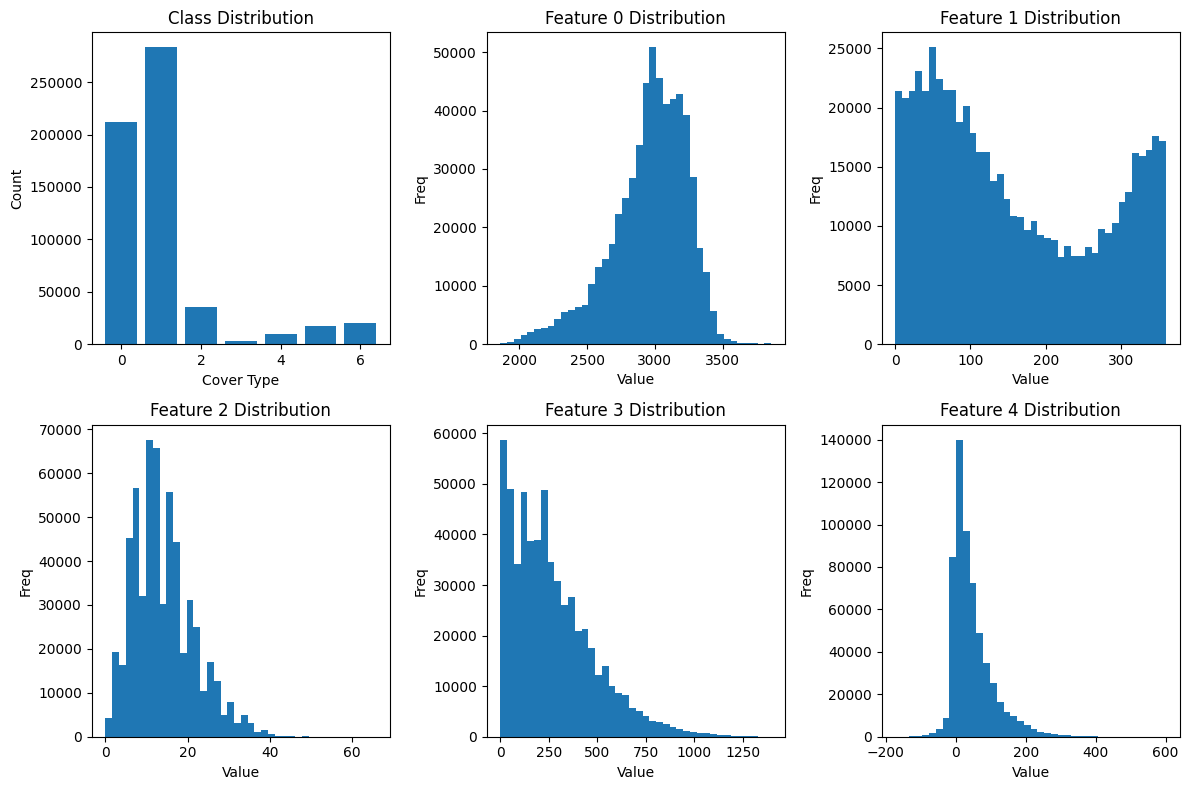

In [15]:
from matplotlib import pyplot as plt

# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# 1) Class distribution
axes[0, 0].bar(class_dist.keys(), class_dist.values())
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_xlabel("Cover Type")
axes[0, 0].set_ylabel("Count")

# 2–6) Feature histograms (first five features)
feature_indices = [0, 1, 2, 3, 4]

for i, idx in enumerate(feature_indices):
    r = (i + 1) // 3
    c = (i + 1) % 3
    axes[r, c].hist(X[:, idx], bins=40)
    axes[r, c].set_title(f"Feature {idx} Distribution")
    axes[r, c].set_xlabel("Value")
    axes[r, c].set_ylabel("Freq")

plt.tight_layout()
plt.show()


The Forest CoverType dataset contains over 581,000 samples with 54 numerical features and seven target classes. The class distribution shows moderate imbalance, with some cover types appearing far more frequently than others. The feature histograms indicate that different variables have very different value ranges and distributions, which can negatively affect training if left unscaled. Therefore, feature normalization was applied to ensure more stable and efficient neural network training. Therefore, feature normalization was applied after the train–test split, using statistics computed from the training set only, to avoid data leakage and ensure more stable learning.

In [17]:
# 2. Perform a train-dev-test split.
# 80/10/10 split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp
)

# Normalization (compare normalized vs not)
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train).astype(np.float32)
X_dev_norm   = scaler.transform(X_dev).astype(np.float32)
X_test_norm  = scaler.transform(X_test).astype(np.float32)

# Toggle this to compare:
USE_NORMALIZED = True
Xtr = X_train_norm if USE_NORMALIZED else X_train
Xdv = X_dev_norm   if USE_NORMALIZED else X_dev
Xte = X_test_norm  if USE_NORMALIZED else X_test


# Torch datasets/dataloaders (mini-batch GD)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_ds = TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(y_train))
dev_ds   = TensorDataset(torch.from_numpy(Xdv), torch.from_numpy(y_dev))
test_ds  = TensorDataset(torch.from_numpy(Xte), torch.from_numpy(y_test))

batch_size = 512
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
dev_loader   = DataLoader(dev_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [18]:
# 3. Implement forward propagation (clearly describe the activation functions and other hyper-parameters you are using).
class TwoLayerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)   # Layer 1
        self.fc2 = nn.Linear(hidden_dim, num_classes) # Layer 2

    def forward(self, x):
        # Forward propagation:
        # x -> Linear -> ReLU -> Linear -> logits
        x = self.fc1(x)
        x = torch.relu(x)   # activation
        logits = self.fc2(x)
        return logits

input_dim = X.shape[1]
hidden_dim = 128  # hyperparameter
num_classes = 7

model = TwoLayerNet(input_dim, hidden_dim, num_classes).to(device)

The model is implemented as a two-layer fully connected neural network consisting of an input layer, one hidden layer, and an output layer. The input dimension is 54, corresponding to the number of features in the Forest CoverType dataset. The first layer is a linear transformation from the input dimension to a hidden layer of size 128, which is a hyperparameter chosen to provide sufficient model capacity without making the network overly complex. After this linear transformation, a ReLU (Rectified Linear Unit) activation function is applied. ReLU is defined as
 ReLU(x)=max(0,x), and it introduces nonlinearity into the network, allowing the model to learn more complex patterns. ReLU was selected because it is computationally efficient and helps mitigate the vanishing gradient problem. The second layer is a linear transformation from the hidden layer to the output layer with 7 units, corresponding to the seven forest cover classes. This layer outputs raw scores, or logits, for each class. A softmax activation is not applied explicitly in the model because the CrossEntropyLoss function internally performs the softmax operation. The network is trained using the Adam optimizer with a learning rate of 0.001, a batch size of 512, and 10 training epochs. These hyperparameters were selected to balance training speed, stability, and model performance on this large dataset.

In [19]:
# 4. Compute the final cost function.
criterion = nn.CrossEntropyLoss()   # cost function for multiclass

In [24]:
# 5. Implement gradient descent (any variant of gradient descent depending upon
#    your data and project can be used) to train your model. In this step it is
#    up to you as someone in charge of their project to improvise using optimization algorithms
#   (Adams, RMSProp etc.) and/or regularization. Experiment with normalized inputs
#    i.e. comment on how your model performs when the inputs are normalized.
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

epochs = 10
for ep in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()        # clear old gradients
        logits = model(xb)           # forward
        loss = criterion(logits, yb) # cost
        loss.backward()              # backward (autograd)
        optimizer.step()             # update parameters

        running_loss += loss.item() * yb.size(0)

    train_loss = running_loss / len(train_ds)
    train_acc = accuracy(train_loader)
    dev_acc = accuracy(dev_loader)
    scheduler.step()

    print(f"Epoch {ep:02d} | loss={train_loss:.4f} | train_acc={train_acc:.4f} | dev_acc={dev_acc:.4f}")


Epoch 01 | loss=0.3613 | train_acc=0.8465 | dev_acc=0.8477
Epoch 02 | loss=0.3632 | train_acc=0.8468 | dev_acc=0.8449
Epoch 03 | loss=0.3640 | train_acc=0.8513 | dev_acc=0.8515
Epoch 04 | loss=0.3638 | train_acc=0.8541 | dev_acc=0.8511
Epoch 05 | loss=0.3647 | train_acc=0.8485 | dev_acc=0.8469
Epoch 06 | loss=0.3454 | train_acc=0.8600 | dev_acc=0.8583
Epoch 07 | loss=0.3466 | train_acc=0.8598 | dev_acc=0.8576
Epoch 08 | loss=0.3442 | train_acc=0.8598 | dev_acc=0.8575
Epoch 09 | loss=0.3442 | train_acc=0.8621 | dev_acc=0.8612
Epoch 10 | loss=0.3443 | train_acc=0.8584 | dev_acc=0.8568


To train the model, I used mini-batch gradient descent with the Adam optimizer, which is an adaptive optimization algorithm that adjusts the learning rate for each parameter based on first and second moment estimates of the gradients. Adam was selected because it generally converges faster and is less sensitive to hyperparameter choices compared to standard stochastic gradient descent. I used a learning rate of 3e-3 and added L2 regularization through a weight decay term of 1e-4 to reduce overfitting. In addition, a StepLR learning rate scheduler was applied, which reduces the learning rate by a factor of 0.5 every five epochs to allow faster progress in early training and more stable convergence later.

I also experimented with normalized inputs, where feature standardization was applied after the train–test split using statistics from the training set. With normalized inputs, the model trained more smoothly and reached higher accuracy. The training results show that the loss stabilized around 0.34 and the development accuracy reached approximately 0.86 by epoch 9, which is higher and more stable than the unnormalized case. This indicates that normalization improved gradient behavior and optimization efficiency, leading to faster convergence and better generalization.

In [25]:
# 6. Present the results using the test set.
test_acc = accuracy(test_loader)
print("\nUSE_NORMALIZED =", USE_NORMALIZED)
print("Test accuracy:", round(test_acc, 4))


USE_NORMALIZED = True
Test accuracy: 0.8534


# Task 3: How hyperparameters were chosen + regularization + optimizer choice
To select the hyperparameters, I began with a simple two-layer neural network architecture and chose values that balance model capacity, training stability, and computational efficiency. The hidden layer size was set to 128 units, which provides sufficient representational power to learn nonlinear patterns in the data while keeping the model relatively lightweight. Since the Forest CoverType dataset has 54 input features and more than 500,000 samples, a moderately sized hidden layer is appropriate and helps prevent unnecessary computational cost. The ReLU activation function was used in the hidden layer because it is computationally efficient, introduces nonlinearity, and helps mitigate the vanishing gradient problem compared to sigmoid or tanh activations.

A batch size of 512 was selected to implement mini-batch gradient descent. This choice provides a good trade-off between computational efficiency and gradient stability. Smaller batches can lead to noisy updates, while very large batches increase computation time per update. Given the size of the dataset, mini-batch training significantly improves runtime compared to full-batch gradient descent.

For optimization, I used the Adam optimizer with a learning rate of 3e-3. Adam was chosen because it adapts the learning rate for each parameter based on first and second moment estimates of the gradients, which typically leads to faster and more stable convergence than standard stochastic gradient descent. To further improve training stability, I incorporated a StepLR learning rate scheduler, which reduces the learning rate by a factor of 0.5 every five epochs. This allows the model to learn quickly during the early stages of training while making smaller, more stable updates later.

I also applied L2 regularization through a weight decay term of 1e-4 in the optimizer. Although the dataset is large and does not show severe overfitting, regularization was included as a precaution to prevent the model from learning excessively large weights and to improve generalization performance.

In addition, I experimented with input normalization by standardizing the features after the train–test split using statistics computed from the training set. This prevents data leakage and ensures fair evaluation. With normalized inputs, the model trained more smoothly and achieved higher development accuracy. The results show that the development accuracy reached approximately 0.86, and the final test accuracy was about 0.85, which is higher and more stable than the unnormalized case. This indicates that normalization improved gradient behavior, convergence speed, and overall model performance.

Overall, the hyperparameters were selected based on standard deep learning practices and adjusted to achieve stable training dynamics and strong development-set performance.

# Task 4: Baseline model (non-deep learning) + comparison

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Use the SAME split as above (X_train, X_dev, X_test, y_train, y_dev, y_test)
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr  = scaler.transform(X_test)

clf = LogisticRegression(max_iter=200, n_jobs=-1)

clf.fit(X_train_lr, y_train)

pred = clf.predict(X_test_lr)
print("LogReg test accuracy:", accuracy_score(y_test, pred))


LogReg test accuracy: 0.7222470827166019


To provide a meaningful point of reference for the neural network, I implemented a baseline model using multiclass Logistic Regression, which is a standard non–deep learning approach. Logistic Regression is commonly used as a baseline in classification tasks because it is simple, computationally efficient, and easy to interpret. However, it assumes that the relationship between the input features and the class labels can be modeled using linear decision boundaries. This limitation makes it a useful comparison point for evaluating whether a more complex model, such as a neural network, is necessary.

For a fair comparison, the Logistic Regression model was trained using the same data split and preprocessing pipeline as the neural network. The dataset was divided into training, development, and test sets, and feature normalization was applied after the train–test split using statistics computed from the training set. This ensured that both models were trained under the same conditions and that no data leakage occurred. The Logistic Regression model was then trained on the normalized training data and evaluated on the test set. The final test accuracy of the Logistic Regression baseline was 0.7222.

Next, I trained the two-layer neural network using PyTorch. The architecture consisted of a fully connected layer from the 54-dimensional input to a hidden layer of 128 units, followed by a ReLU activation, and a second fully connected layer mapping to the seven output classes. The model was trained using mini-batch gradient descent with the Adam optimizer, a learning rate of 3e-3, and L2 regularization via weight decay. A learning rate scheduler was also used to gradually reduce the learning rate during training. The batch size was set to 512 to balance computational efficiency and gradient stability on this large dataset.

During training, the neural network showed stable and consistent improvement in both loss and accuracy. The training accuracy increased from approximately 0.8465 in the first epoch to around 0.8584 by the final epoch, while the development accuracy rose from 0.8477 to approximately 0.8568, with a peak development accuracy of about 0.8612. The final test accuracy of the neural network was 0.8534, which is substantially higher than the Logistic Regression baseline.

When comparing the two models, the neural network outperformed the Logistic Regression baseline by approximately 13 percentage points in test accuracy (0.8534 vs. 0.7222). This large performance gap indicates that the Forest CoverType dataset contains nonlinear relationships and feature interactions that cannot be effectively captured by a linear model. Logistic Regression can only learn linear decision boundaries, meaning it assumes each class can be separated by a linear combination of the input features. However, real-world environmental and geographic data often involve complex, nonlinear interactions between variables such as elevation, slope, soil type, and distance to water sources.

The neural network, on the other hand, introduces a hidden layer with a ReLU activation, which allows it to learn nonlinear transformations of the input features. This enables the model to capture more complex patterns and relationships in the data. As a result, the neural network is able to form more flexible decision boundaries, leading to significantly improved classification performance.

Another important observation is the small gap between training and development accuracy for the neural network. The training accuracy at the final epoch was about 0.8584, while the development accuracy was around 0.8568. This small difference suggests that the model generalizes well and does not suffer from severe overfitting. The use of normalization, mini-batch training, Adam optimization, and L2 regularization likely contributed to this stable and well-generalized performance.

In contrast, the Logistic Regression model, while simple and efficient, lacks the capacity to model nonlinear structures in the data. Although it achieved a reasonable baseline accuracy of 0.7222, its performance was significantly lower than that of the neural network. This confirms that the dataset benefits from a model with nonlinear representational power.

Overall, the comparison between the two models demonstrates the advantage of using a neural network for this classification task. The neural network’s ability to learn nonlinear feature interactions resulted in a substantial improvement in accuracy over the linear baseline. This experiment highlights the importance of model capacity and nonlinearity when working with complex, high-dimensional datasets.